### CMOR-izer script adapted from Matt.M and Bettina Gier's CMOR-izer scripts to create historical and ScenarioMIP data files for tas. This will be used for the GWL diagnostic for the REF.


#### Conda environment created with cmor v3.14.2 a recent version of iris and ipykernel to allow interface with Jupyterhub. This was run on JASMIN at CEDA

In [31]:
import cmor  # used for writing files
import iris  # used for reading files -- netCDF4 or xarray could be used here based on preference
import json
import os
import warnings
import iris.quickplot as qplt
import matplotlib.pyplot as plt
from iris.time import PartialDateTime


In [11]:
{i:j for i,j in vars(cmor).items() if "VERSION" in i}

{'CMOR_VERSION_MAJOR': 3,
 'CMOR_VERSION_MINOR': 14,
 'CMOR_VERSION_PATCH': 2,
 'CMOR_CF_VERSION_MAJOR': 1,
 'CMOR_CF_VERSION_MINOR': 7}

In [18]:
#read historical and scenarioMIP from CMIP6 and concatenate cubes

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cubelist_hist = iris.load('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/tas/gn/latest/tas*.nc')
    
for i in cubelist_hist:
    i.attributes = {}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cubelist_scenario = iris.load('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp126/r1i1p1f2/Amon/tas/gn/latest/tas_*.nc')

for i in cubelist_scenario:
    i.attributes = {}

cubelist_hist.extend(cubelist_scenario)

tas_cube_hist_ssp = cubelist_hist.concatenate_cube()
print(tas_cube_hist_ssp)

#separate out new CMIP7 hist and scenario
desired_date = PartialDateTime(year=2021, month=12, day=30)
constraint_hist = iris.Constraint(time = lambda t: t.point <= desired_date)
tas_hist_cube = tas_cube_hist_ssp.extract(constraint_hist)
constraint_ssp = iris.Constraint(time = lambda t: t.point > desired_date)
tas_ssp_cube = tas_cube_hist_ssp.extract(constraint_ssp)

print(tas_hist_cube)
print(tas_ssp_cube)


air_temperature / (K)               (time: 3012; latitude: 144; longitude: 192)
    Dimension coordinates:
        time                             x               -               -
        latitude                         -               x               -
        longitude                        -               -               x
    Scalar coordinates:
        height                      1.5 m
    Cell methods:
        0                           area: time: mean
air_temperature / (K)               (time: 2064; latitude: 144; longitude: 192)
    Dimension coordinates:
        time                             x               -               -
        latitude                         -               x               -
        longitude                        -               -               x
    Scalar coordinates:
        height                      1.5 m
    Cell methods:
        0                           area: time: mean
air_temperature / (K)               (time: 948; latitude: 144;

/home/users/ranjinis/projects/src/ref_data_cmorizer/.pixi/envs/default/lib/python3.13/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


#### CMOR input json

In [19]:
#create CMOR info for historical

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "tables/CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "tables/CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": "tables-cvs/cmor-cvs.json",
    "activity_id": "CMIP",
    "branch_time_in_child": 30.0,
    "branch_time_in_parent": 10800.0,
    "calendar": "360_day",
    "drs_specs": "MIP-DRS7",
    "data_specs_version": "MIP-DS7.1.0.0",
    "experiment_id": "historical",
    "forcing_index": "f3",
    "grid_label": "g999",
    "initialization_index": "i1",
    "institution_id": "MOHC",
    "license_id": "CC-BY-4.0",
    "nominal_resolution": "100 km",
    "outpath": ".",
    "parent_mip_era": "CMIP7",
    "parent_time_units": "days since 1850-01-01",
    "parent_activity_id": "CMIP",
    "parent_source_id": "DUMMY-MODEL",
    "parent_experiment_id": "piControl",
    "parent_variant_label": "r1i1p1f3",
    "physics_index": "p1",
    "realization_index": "r1",
    "source_id": "DUMMY-MODEL",
    "tracking_prefix": "hdl:21.14107",
    "frequency": "mon",
    "region": "glb",
    "mip_era": "CMIP7",
}

with open('input.json', 'w') as fh:
    json.dump(DATASET_INFO, fh, indent=2)

cmor.setup(inpath="tables", netcdf_file_action=cmor.CMOR_REPLACE)

cmor.dataset_json('input.json')

realm = "atmos"
cmor.load_table(f'CMIP7_{realm}.json')


0

In [20]:
#create coordinate axes, add data and write new historical file

# construct latitude and longitude coords
cmorlat = cmor.axis("latitude",
                    coord_vals=hist_cube.coord('latitude').points,
                    cell_bounds=hist_cube.coord('latitude').bounds,
                    units="degrees_north")
cmorlon = cmor.axis("longitude",
                    coord_vals=hist_cube.coord('longitude').points,
                    cell_bounds=hist_cube.coord('longitude').bounds,
                    units="degrees_east")
# construct time coord in a way that we can update with points and bounds later
cmortime = cmor.axis("time", units="days since 1850-01-01")
# define CMOR variable object
axes = [cmortime, cmorlat, cmorlon]

variable = "tas_tavg-h2m-hxy-u"
cmortas = cmor.variable(variable, "K", axes)

# manually apply cell measures
region = DATASET_INFO['region']
frequency = DATASET_INFO['frequency']
cmip7_compound_name = ".".join([realm] + variable.split("_") + [frequency, region])

# apply cell measures 
with open('tables/CMIP7_cell_measures.json') as fh:
    cell_measures = json.load(fh)

variable_cell_measures = cell_measures['cell_measures'][cmip7_compound_name]

cmor.set_variable_attribute(cmortas, "cell_measures", "c", variable_cell_measures)

# override long names if necessary

with open('tables/CMIP7_long_name_overrides.json') as fh:
    long_name_overrides = json.load(fh)

if cmip7_compound_name in long_name_overrides['long_name_overrides']:
    new_long_name = long_name_overrides['long_name_overrides'][cmip7_compound_name]
    cmor.set_variable_attribute(cmortas, "long_name", "c", new_long_name)

cmor.set_variable_attribute(cmortas, "cell_measures", "c", variable_cell_measures)


# slice up data into N time record chunks and push through CMOR.write
data_points = len(tas_hist_cube.coord("time").points)
N = 50
for i in range(0, data_points, N):
    if i+N < data_points:
        s = slice(i, i+N)
    else:
        s = slice(i, data_points)
    cube_slice = tas_hist_cube[s]
    cmor.write(
        cmortas,
        cube_slice.data, 
        time_vals=cube_slice.coord('time').points, 
        time_bnds=cube_slice.coord('time').bounds)

# close the file (sorts the full naming)
cmor.close(cmortas, file_name=True)

'./MIP-DRS7/CMIP7/CMIP/MOHC/DUMMY-MODEL/historical/r1i1p1f3/glb/mon/tas/tavg-h2m-hxy-u/g999/v20260601/tas_tavg-h2m-hxy-u_mon_glb_g999_DUMMY-MODEL_historical_r1i1p1f3_185001-202112.nc'

In [21]:
#Prepare ScenarioMIP file for CMIP7

DATASET_INFO['activity_id'] = "ScenarioMIP"
DATASET_INFO['experiment_id'] = "scen7-l"
DATASET_INFO['parent_experiment_id'] = "historical"

with open('input.json', 'w') as fh:
    json.dump(DATASET_INFO, fh, indent=2)

cmor.setup(inpath="tables", netcdf_file_action=cmor.CMOR_REPLACE)

cmor.dataset_json('input.json')

realm = "atmos"
cmor.load_table(f'CMIP7_{realm}.json')


0

In [22]:
#create coordinate axes, add data and write new ScenarioMIP file

# construct latitude and longitude coords
cmorlat = cmor.axis("latitude",
                    coord_vals=hist_cube.coord('latitude').points,
                    cell_bounds=hist_cube.coord('latitude').bounds,
                    units="degrees_north")
cmorlon = cmor.axis("longitude",
                    coord_vals=hist_cube.coord('longitude').points,
                    cell_bounds=hist_cube.coord('longitude').bounds,
                    units="degrees_east")
# construct time coord in a way that we can update with points and bounds later
cmortime = cmor.axis("time", units="days since 1850-01-01")
# define CMOR variable object
axes = [cmortime, cmorlat, cmorlon]

variable = "tas_tavg-h2m-hxy-u"
cmortas = cmor.variable(variable, "K", axes)

# manually apply cell measures
region = DATASET_INFO['region']
frequency = DATASET_INFO['frequency']
cmip7_compound_name = ".".join([realm] + variable.split("_") + [frequency, region])

# apply cell measures 
with open('tables/CMIP7_cell_measures.json') as fh:
    cell_measures = json.load(fh)

variable_cell_measures = cell_measures['cell_measures'][cmip7_compound_name]

cmor.set_variable_attribute(cmortas, "cell_measures", "c", variable_cell_measures)

# override long names if necessary

with open('tables/CMIP7_long_name_overrides.json') as fh:
    long_name_overrides = json.load(fh)

if cmip7_compound_name in long_name_overrides['long_name_overrides']:
    new_long_name = long_name_overrides['long_name_overrides'][cmip7_compound_name]
    cmor.set_variable_attribute(cmortas, "long_name", "c", new_long_name)

cmor.set_variable_attribute(cmortas, "cell_measures", "c", variable_cell_measures)


# slice up data into N time record chunks and push through CMOR.write
data_points = len(tas_ssp_cube.coord("time").points)
N = 50
for i in range(0, data_points, N):
    if i+N < data_points:
        s = slice(i, i+N)
    else:
        s = slice(i, data_points)
    cube_slice = tas_ssp_cube[s]
    cmor.write(
        cmortas,
        cube_slice.data, 
        time_vals=cube_slice.coord('time').points, 
        time_bnds=cube_slice.coord('time').bounds)

# close the file (sorts the full naming)
cmor.close(cmortas, file_name=True)

'./MIP-DRS7/CMIP7/ScenarioMIP/MOHC/DUMMY-MODEL/scen7-l/r1i1p1f3/glb/mon/tas/tavg-h2m-hxy-u/g999/v20260601/tas_tavg-h2m-hxy-u_mon_glb_g999_DUMMY-MODEL_scen7-l_r1i1p1f3_202201-210012.nc'

/home/users/ranjinis/projects/src/ref_data_cmorizer/.pixi/envs/default/lib/python3.13/site-packages/iris/fileformats/cf.py:934: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'tas'
  warnings.warn(
/home/users/ranjinis/projects/src/ref_data_cmorizer/.pixi/envs/default/lib/python3.13/site-packages/iris/fileformats/cf.py:934: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'tas'
  warnings.warn(


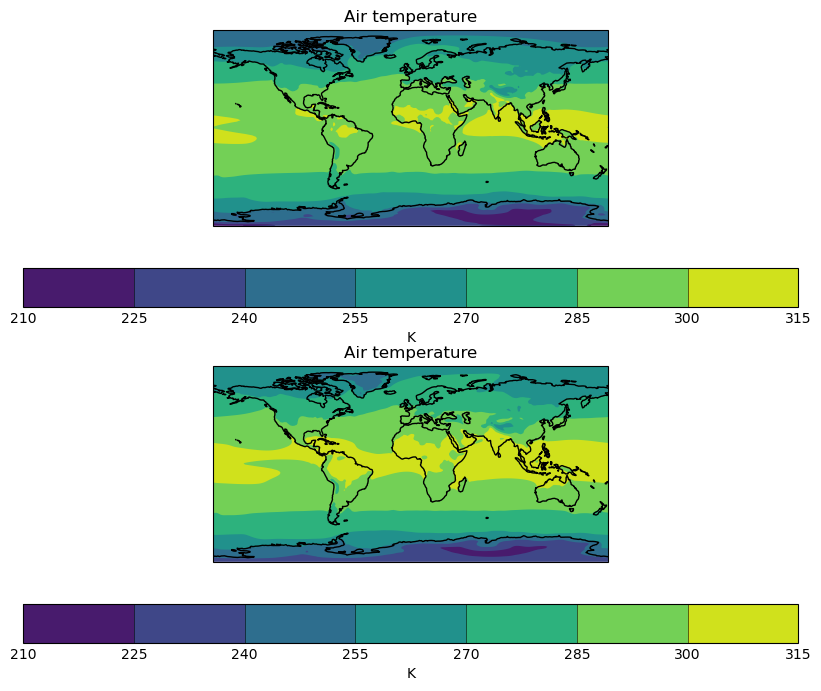

In [34]:
#check data
plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
cmip7_dir = './MIP-DRS7/CMIP7/'

#read hist data

filename = './MIP-DRS7/CMIP7/CMIP/MOHC/DUMMY-MODEL/historical/r1i1p1f3/glb/mon/tas/tavg-h2m-hxy-u/g999/v20260601/tas_tavg-h2m-hxy-u_mon_glb_g999_DUMMY-MODEL_historical_r1i1p1f3_185001-202112.nc'

hist_cube = iris.load_cube(filename)
hist_cube = hist_cube.collapsed('time',iris.analysis.MEAN)
qplt.contourf(hist_cube)
plt.gca().coastlines()

plt.subplot(2,1,2)

filename = './MIP-DRS7/CMIP7/ScenarioMIP/MOHC/DUMMY-MODEL/scen7-l/r1i1p1f3/glb/mon/tas/tavg-h2m-hxy-u/g999/v20260601/tas_tavg-h2m-hxy-u_mon_glb_g999_DUMMY-MODEL_scen7-l_r1i1p1f3_202201-210012.nc'

ssp_cube = iris.load_cube(filename)
ssp_cube = ssp_cube.collapsed('time',iris.analysis.MEAN)
qplt.contourf(ssp_cube)
plt.gca().coastlines()